# Machine Learning per l'Analisi Finanziaria

## Lezione 04 — Feature importance e interpretabilità

**Authors:**
- Enrico Huber
- Pietro Soglia

**Emails:**
- enrico.huber@bip-group.com
- pietro.soglia@bip-group.com

**Last updated:** 2026-03-16

## Obiettivi di apprendimento

- Comprendere la **feature importance** attraverso tre prospettive complementari
  (Gini, Permutation, SHAP) e ragionare sulle discrepanze tra i metodi.
- Utilizzare **SHAP** come framework unificante per interpretabilità globale
  e locale, scoprendo non solo QUANTO una feature conta ma COME e IN CHE
  DIREZIONE influenza le predizioni.
- Costruire un **profilo cliente a rischio** basato sull'evidenza interpretativa,
  distinguendo feature azionabili da non-azionabili.
- Sperimentare il **re-training** con subset di feature per validare le scoperte.
- Analizzare le **implicazioni regolamentari e di fairness** (EBA, GDPR,
  attributi protetti) nel contesto della churn prediction finanziaria.

## Outline

### BLOCCO A — Fondamenta: cosa sappiamo e cosa vogliamo scoprire
1. Setup, percorsi e costanti
2. Caricamento modello e dati
3. Ricapitolazione del Gini importance (punto di partenza)

### BLOCCO B — Permutation Importance: sfida al ranking Gini
4. Permutation importance su validation set
5. Confronto Gini vs Permutation: dove concordano e dove no

### BLOCCO C — SHAP: il framework definitivo per l'interpretabilità
6. Introduzione concettuale a SHAP
7. Calcolo degli SHAP values
8. SHAP bar plot: ranking globale definitivo
9. SHAP beeswarm plot: direzione degli effetti

### BLOCCO D — Analisi delle relazioni: SHAP dependence plots
10. SHAP dependence plot per le top feature

### BLOCCO E — Interpretabilità locale: spiegare singole predizioni
11. Selezione di clienti campione
12. SHAP waterfall plots

### BLOCCO F — Profilo cliente a rischio: dall'interpretabilità all'azione
13. Segmentazione basata sui SHAP values
14. Costruzione del profilo tipo

### BLOCCO G — Re-training: il modello può essere semplificato?
15. Esperimento: modello con sole top-K feature
16. Analisi del costo di semplificazione

### BLOCCO H — Fairness e implicazioni regolamentari
17. Analisi SHAP su attributi protetti
18. Contesto regolamentare

### BLOCCO I — Chiusura
19. Riepilogo delle scoperte
20. Domande guidate
21. Bridge verso la Lezione 5

---
## BLOCCO A — Fondamenta: cosa sappiamo e cosa vogliamo scoprire

---

## 1. Setup, percorsi e costanti

Nella Lezione 3 abbiamo selezionato un Random Forest come miglior modello
(AUC = 0.854 su test). Sappiamo **che** funziona. Ora dobbiamo capire
**perché** funziona: quali feature guidano le decisioni, come interagiscono,
e cosa significa per il business. Un modello che funziona ma non si capisce
non ha valore in finanza.

In [1]:
from __future__ import annotations

import json
import random
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

try:
    from IPython.display import display  # type: ignore
except Exception:  # pragma: no cover

    def display(x):  # type: ignore
        """Fallback display per esecuzione fuori da Jupyter."""
        print(x)


warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)


def resolve_project_root() -> Path:
    """Risolve la root del repository indipendentemente dalla cwd."""
    start_points = [Path.cwd().resolve()]
    if "__file__" in globals():
        start_points.append(Path(__file__).resolve().parent)
    for start in start_points:
        for candidate in [start, *start.parents]:
            if (candidate / "data" / "archive.zip").exists() and (
                candidate / "notebooks"
            ).exists():
                return candidate
    raise FileNotFoundError(
        "Impossibile determinare la root del progetto. "
        "Atteso un percorso contenente data/archive.zip e notebooks/."
    )


ROOT = resolve_project_root()
DATA_OUT_DIR = ROOT / "outputs" / "data"
FIGURES_DIR = ROOT / "outputs" / "figures"

for _dir in [DATA_OUT_DIR, FIGURES_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")


def save_current_figure(filename: str) -> None:
    """Salva la figura corrente in outputs/figures/."""
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=120, bbox_inches="tight")
    print(f"Figura salvata: {FIGURES_DIR / filename}")


def load_preprocessed_split(
    prefix: str,
) -> tuple[np.ndarray, np.ndarray]:
    """Carica X e y da parquet per uno split (train, val o test).

    Parameters
    ----------
    prefix : str
        Uno tra 'train', 'val', 'test'.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Coppia (X, y) come array numpy.

    Raises
    ------
    FileNotFoundError
        Se i file parquet attesi non esistono.
    """
    x_path = DATA_OUT_DIR / f"lesson_02_X_{prefix}.parquet"
    y_path = DATA_OUT_DIR / f"lesson_02_y_{prefix}.parquet"
    for p in [x_path, y_path]:
        if not p.exists():
            raise FileNotFoundError(
                f"File parquet non trovato: {p}\n"
                "Esegui prima il notebook della Lezione 2."
            )
    X = pd.read_parquet(x_path).values
    y = pd.read_parquet(y_path).squeeze().values
    return X, y

## 2. Caricamento modello e dati

Carichiamo il modello Random Forest addestrato nella Lezione 3, insieme
ai dataset preprocessati della Lezione 2 e alle metriche salvate. Questo
ci permette di non dover riaddestrare nulla e concentrarci sull'analisi
interpretativa.

In [2]:
# --- Modello RF dalla Lezione 3 ---
model_path = DATA_OUT_DIR / "lesson_03_best_model.pkl"
if not model_path.exists():
    raise FileNotFoundError(
        f"Modello non trovato: {model_path}\n"
        "Esegui prima il notebook della Lezione 3."
    )
rf = joblib.load(model_path)
print(f"Modello caricato: {rf}")
print(f"  n_estimators: {rf.n_estimators}")
print(f"  class_weight: {rf.class_weight}")
print(f"  random_state: {rf.random_state}")

Modello caricato: RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)
  n_estimators: 200
  class_weight: balanced
  random_state: 42


In [3]:
# --- Metriche dalla Lezione 3 ---
metrics_path = DATA_OUT_DIR / "lesson_03_metrics.json"
with open(metrics_path) as fh:
    l3_metrics = json.load(fh)

print("=== Riepilogo metriche Lezione 3 ===\n")
for split in ["train", "val", "test"]:
    m = l3_metrics[split]
    print(
        f"  {split:5s}  AUC={m['roc_auc']:.4f}  "
        f"F1={m['f1']:.4f}  "
        f"Recall={m['recall']:.4f}  "
        f"Precision={m['precision']:.4f}"
    )
print(f"\n  Soglia ottimale: {l3_metrics['best_threshold']}")

=== Riepilogo metriche Lezione 3 ===

  train  AUC=1.0000  F1=0.9971  Recall=1.0000  Precision=0.9943
  val    AUC=0.8733  F1=0.6471  Recall=0.6740  Precision=0.6222
  test   AUC=0.8539  F1=0.6047  Recall=0.6314  Precision=0.5801

  Soglia ottimale: 0.305


In [4]:
# --- Dataset preprocessato dalla Lezione 2 ---
X_train, y_train = load_preprocessed_split("train")
X_val, y_val = load_preprocessed_split("val")
X_test, y_test = load_preprocessed_split("test")

with open(DATA_OUT_DIR / "lesson_02_feature_names.json") as fh:
    feature_names = json.load(fh)

BEST_THRESHOLD = l3_metrics["best_threshold"]

print(f"Train: {X_train.shape}  churn={y_train.mean():.2%}")
print(f"Val:   {X_val.shape}  churn={y_val.mean():.2%}")
print(f"Test:  {X_test.shape}  churn={y_test.mean():.2%}")
print(f"\nFeature totali: {len(feature_names)}")

Train: (6000, 20)  churn=20.38%
Val:   (2000, 20)  churn=20.40%
Test:  (2000, 20)  churn=20.35%

Feature totali: 20


Il modello RF ha performance solida (AUC test = 0.854) e generalizza bene
(gap val-test < 0.02). Ma un modello in ambito finanziario non può essere
una "scatola nera": dobbiamo capire **quali feature guidano le decisioni** e
**come** le influenzano. Cominciamo dal punto in cui ci eravamo fermati nella
Lezione 3: la **Gini importance**.

## 3. Ricapitolazione del Gini importance (punto di partenza)

La Gini importance (o Mean Decrease Impurity) è il metodo di feature importance
nativo del Random Forest. Misura quanto ciascuna feature contribuisce a ridurre
l'impurità di Gini media pesata attraverso tutti gli alberi della foresta.
Nella Lezione 3 l'avevamo già calcolata — ora la riproduciamo dal modello
caricato e la esaminiamo con occhio critico, ponendoci una domanda chiave:
**possiamo fidarci di questo ranking?**

In [5]:
# Calcolo Gini importance dal modello caricato
gini_imp = pd.Series(rf.feature_importances_, index=feature_names)
gini_imp = gini_imp.sort_values(ascending=False)

print("=== Gini Importance (top-20) ===\n")
for i, (feat, imp) in enumerate(gini_imp.items(), 1):
    print(f"  {i:2d}. {feat:<35s} {imp:.4f}  ({imp:.1%})")

=== Gini Importance (top-20) ===

   1. num__Age                            0.2189  (21.9%)
   2. num__NumOfProducts                  0.1086  (10.9%)
   3. num__EstimatedSalary                0.0990  (9.9%)
   4. num__Point Earned                   0.0989  (9.9%)
   5. num__CreditScore                    0.0965  (9.7%)
   6. num__Balance                        0.0952  (9.5%)
   7. num__Tenure                         0.0616  (6.2%)
   8. num__Satisfaction Score             0.0417  (4.2%)
   9. num__IsActiveMember                 0.0328  (3.3%)
  10. cat__Geography_Germany              0.0231  (2.3%)
  11. num__HasCrCard                      0.0158  (1.6%)
  12. num__balance_is_zero                0.0128  (1.3%)
  13. cat__Geography_France               0.0126  (1.3%)
  14. cat__Card Type_SILVER               0.0125  (1.3%)
  15. cat__Card Type_PLATINUM             0.0124  (1.2%)
  16. cat__Card Type_DIAMOND              0.0121  (1.2%)
  17. cat__Gender_Male                    0.0121  (1

Figura salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_04_gini_importance_recap.png


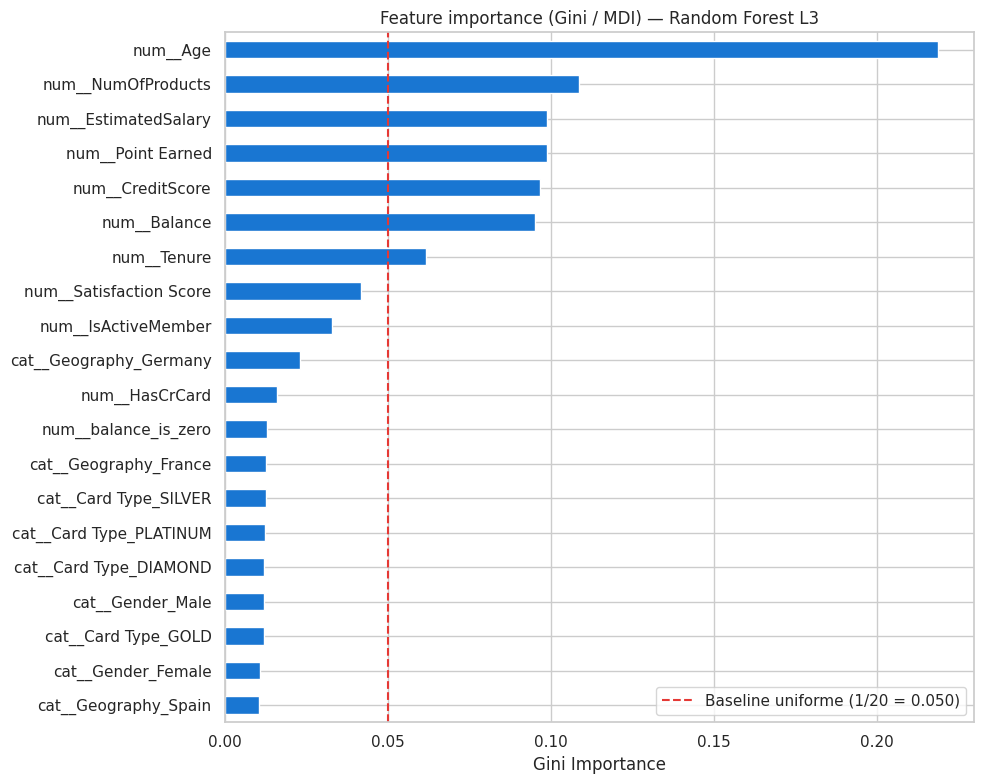

In [6]:
# Bar chart Gini importance
fig, ax = plt.subplots(figsize=(10, 8))
gini_imp.sort_values().plot.barh(ax=ax, color="#1976D2", edgecolor="white")
ax.axvline(
    1 / len(feature_names),
    color="#E53935",
    ls="--",
    lw=1.5,
    label=f"Baseline uniforme (1/{len(feature_names)} = {1/len(feature_names):.3f})",
)
ax.set_xlabel("Gini Importance")
ax.set_title("Feature importance (Gini / MDI) — Random Forest L3")
ax.legend(loc="lower right")
save_current_figure("lesson_04_gini_importance_recap.png")
plt.show()

### Osservazioni sulla Gini importance

Il ranking Gini conferma quanto osservato nella Lezione 3:

- **`num__Age`** domina con circa il 22% dell'importanza totale — coerente
  con la correlazione r = +0.285 identificata nell'EDA (Lezione 1).
- **`num__NumOfProducts`** (~11%) e **`num__IsActiveMember`** (~7%) occupano
  posizioni di rilievo, in linea con le evidenze EDA.
- **Sorpresa**: `num__EstimatedSalary` (~10%) e `num__Point Earned` (~10%)
  si posizionano in alto **nonostante** abbiano correlazione lineare ≈ 0 con
  il target nella Lezione 1.

Questa discrepanza solleva un dubbio legittimo. La Gini importance ha un difetto
noto: **favorisce le feature continue con molti valori distinti**, perché queste
offrono più opportunità di split e quindi più occasioni per ridurre l'impurità,
anche quando il segnale predittivo è debole. feature come EstimatedSalary
(continua, alta cardinalità) potrebbero essere "inflazionate" dalla Gini.

**Ipotesi da verificare**: se il ranking è genuino, un metodo alternativo
(insensibile alla cardinalità) dovrebbe confermarlo. Se non lo conferma,
la Gini ci stava ingannando. Verifichiamolo con la **Permutation Importance**.

---
## BLOCCO B — Permutation Importance: sfida al ranking Gini

---

## 4. Permutation importance su validation set

La Permutation Importance opera in modo completamente diverso dalla Gini:
per ogni feature, permuta casualmente i suoi valori nel dataset e misura
quanto peggiora la metrica di valutazione (nel nostro caso ROC-AUC).
Se la feature è realmente importante, la permutazione distrugge il segnale
e la metrica cala drasticamente. Se non lo è, la permutazione non cambia
nulla.

Vantaggi cruciali rispetto alla Gini:
- È **model-agnostic**: funziona su qualsiasi modello
- È calcolata su un **set di validazione** (non sul training)
- Non è influenzata dalla cardinalità della feature

In [7]:
perm_result = permutation_importance(
    rf,
    X_val,
    y_val,
    n_repeats=30,
    random_state=SEED,
    scoring="roc_auc",
)

perm_imp = pd.DataFrame(
    {
        "mean": perm_result.importances_mean,
        "std": perm_result.importances_std,
    },
    index=feature_names,
).sort_values("mean", ascending=False)

print("=== Permutation Importance (top-20) ===\n")
for i, (feat, row) in enumerate(perm_imp.iterrows(), 1):
    print(f"  {i:2d}. {feat:<35s} {row['mean']:.4f} ± {row['std']:.4f}")

=== Permutation Importance (top-20) ===

   1. num__Age                            0.1366 ± 0.0106
   2. num__NumOfProducts                  0.1112 ± 0.0079
   3. num__IsActiveMember                 0.0304 ± 0.0042
   4. num__Balance                        0.0236 ± 0.0040
   5. cat__Geography_Germany              0.0151 ± 0.0028
   6. num__balance_is_zero                0.0055 ± 0.0021
   7. num__Point Earned                   0.0037 ± 0.0012
   8. cat__Geography_Spain                0.0013 ± 0.0008
   9. cat__Gender_Female                  0.0012 ± 0.0016
  10. num__EstimatedSalary                0.0006 ± 0.0023
  11. num__CreditScore                    0.0006 ± 0.0024
  12. num__HasCrCard                      0.0005 ± 0.0011
  13. cat__Card Type_GOLD                 0.0004 ± 0.0007
  14. cat__Card Type_DIAMOND              0.0002 ± 0.0009
  15. num__Tenure                         -0.0000 ± 0.0019
  16. num__Satisfaction Score             -0.0001 ± 0.0016
  17. cat__Gender_Male       

Figura salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_04_permutation_importance.png


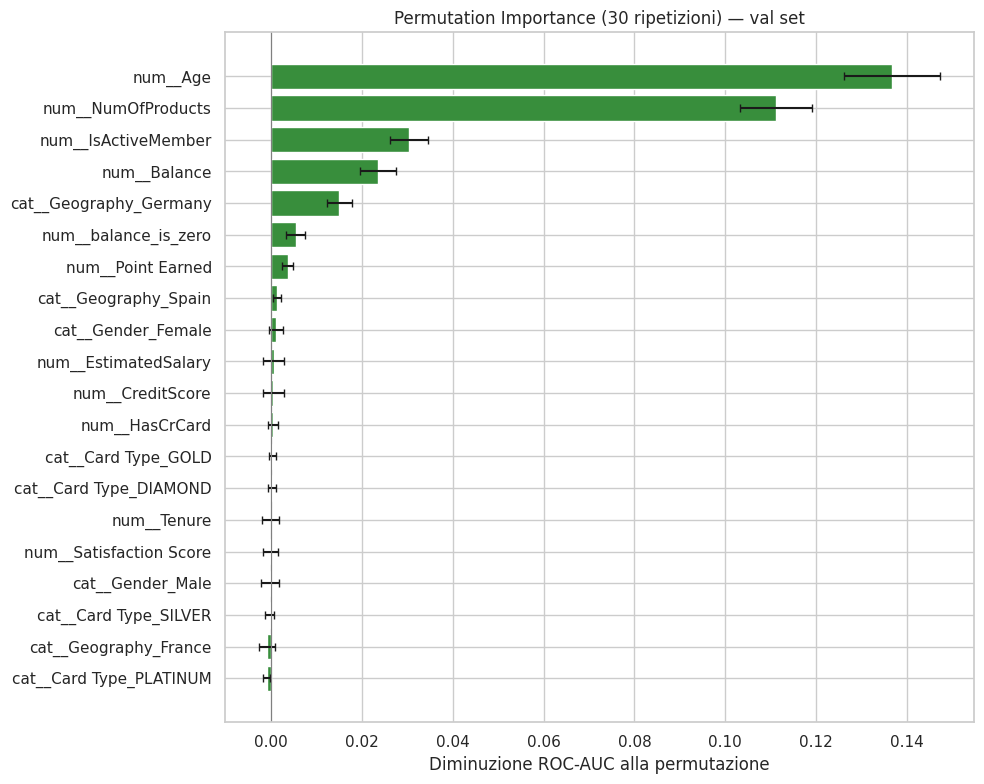

In [8]:
# Bar chart permutation importance con barre d'errore
fig, ax = plt.subplots(figsize=(10, 8))
perm_sorted = perm_imp.sort_values("mean")
ax.barh(
    range(len(perm_sorted)),
    perm_sorted["mean"],
    xerr=perm_sorted["std"],
    color="#388E3C",
    edgecolor="white",
    capsize=3,
)
ax.set_yticks(range(len(perm_sorted)))
ax.set_yticklabels(perm_sorted.index)
ax.axvline(0, color="grey", ls="-", lw=0.8)
ax.set_xlabel("Diminuzione ROC-AUC alla permutazione")
ax.set_title("Permutation Importance (30 ripetizioni) — val set")
save_current_figure("lesson_04_permutation_importance.png")
plt.show()

## 5. Confronto Gini vs Permutation: dove concordano e dove no

Ora abbiamo due ranking indipendenti. Il confronto diretto ci dice quali
feature sono genuinamente importanti (confermate da entrambi i metodi) e
quali potrebbero essere artefatti della Gini.

In [9]:
# Tabella confronto ranking
gini_rank = gini_imp.rank(ascending=False).astype(int)
perm_rank = perm_imp["mean"].rank(ascending=False).astype(int)

comparison = pd.DataFrame(
    {
        "Gini_value": gini_imp,
        "Gini_rank": gini_rank,
        "Perm_value": perm_imp["mean"],
        "Perm_rank": perm_rank,
        "Rank_change": gini_rank - perm_rank,
    }
).sort_values("Gini_rank")

print("=== Confronto ranking: Gini vs Permutation ===\n")
print("  Rank_change > 0 → la feature SALE nel ranking Permutation")
print("  Rank_change < 0 → la feature SCENDE nel ranking Permutation\n")
display(comparison)

=== Confronto ranking: Gini vs Permutation ===

  Rank_change > 0 → la feature SALE nel ranking Permutation
  Rank_change < 0 → la feature SCENDE nel ranking Permutation



,Gini_value,Gini_rank,Perm_value,Perm_rank,Rank_change
num__Age,0.2189,1,0.1366,1,0
num__NumOfProducts,0.1086,2,0.1112,2,0
num__EstimatedSalary,0.0990,3,0.0006,10,-7
num__Point Earned,0.0989,4,0.0037,7,-3
num__CreditScore,0.0965,5,0.0006,11,-6
num__Balance,0.0952,6,0.0236,4,2
num__Tenure,0.0616,7,-0.0000,15,-8
num__Satisfaction Score,0.0417,8,-0.0001,16,-8
num__IsActiveMember,0.0328,9,0.0304,3,6
cat__Geography_Germany,0.0231,10,0.0151,5,5


Figura salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_04_gini_vs_perm_scatter.png


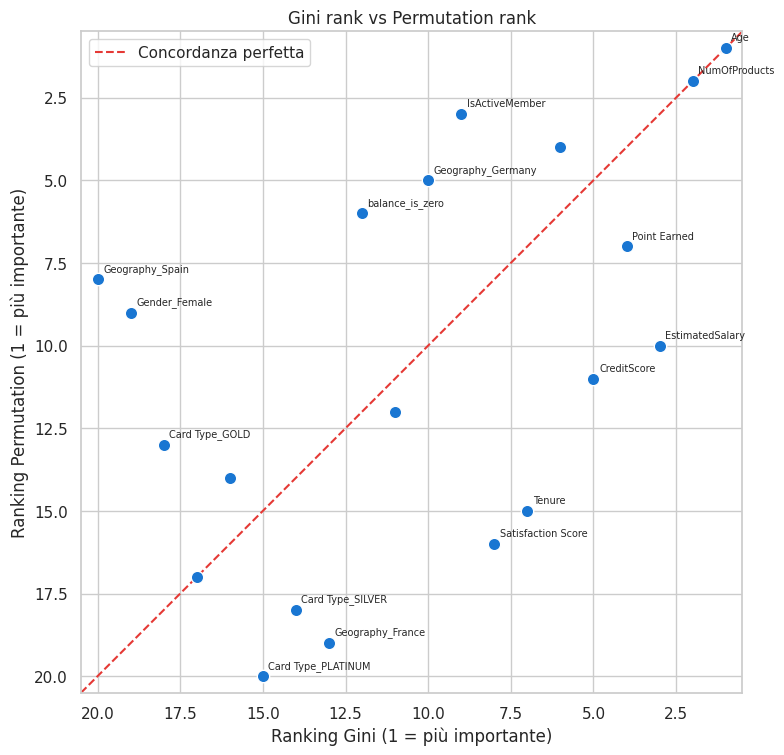

In [10]:
# Scatter plot: Gini rank vs Permutation rank
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(
    comparison["Gini_rank"],
    comparison["Perm_rank"],
    s=80,
    c="#1976D2",
    edgecolors="white",
    zorder=3,
)
# Linea diagonale (concordanza perfetta)
lims = [0.5, len(feature_names) + 0.5]
ax.plot(lims, lims, "--", color="#E53935", lw=1.5, label="Concordanza perfetta")

# Annota le feature più interessanti (quelle con rank_change grande)
for feat, row in comparison.iterrows():
    if abs(row["Rank_change"]) >= 3 or row["Gini_rank"] <= 5:
        short_name = feat.replace("num__", "").replace("cat__", "")
        ax.annotate(
            short_name,
            (row["Gini_rank"], row["Perm_rank"]),
            fontsize=7,
            ha="left",
            va="bottom",
            xytext=(4, 4),
            textcoords="offset points",
        )

ax.set_xlabel("Ranking Gini (1 = più importante)")
ax.set_ylabel("Ranking Permutation (1 = più importante)")
ax.set_title("Gini rank vs Permutation rank")
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_aspect("equal")
save_current_figure("lesson_04_gini_vs_perm_scatter.png")
plt.show()

### Analisi delle discrepanze

Il confronto Gini vs Permutation rivela pattern molto interessanti che
confermano il nostro sospetto iniziale:

**Feature stabili (confermate da entrambi i metodi):**
- `num__Age` resta saldamente al **1° posto** in entrambi i ranking
  (Gini: 21.9%, Perm: 0.137 drop AUC) — importanza genuina e robusta.
- `num__NumOfProducts` si conferma al **2° posto** in entrambi i metodi
  (Gini: 10.9%, Perm: 0.111) — segnale reale.

**Feature che salgono nel ranking Permutation (la Gini le sottostimava):**
- `num__IsActiveMember`: da **#9 Gini → #3 Permutation** (+6 posizioni).
  La Gini la penalizzava perché è binaria (solo 2 valori → pochi split),
  ma la Permutation rivela che il suo contributo alla AUC è sostanziale
  (0.030 drop).
- `cat__Geography_Germany`: da **#10 Gini → #5 Permutation** (+5). L'effetto
  geografico è più rilevante di quanto la Gini suggerisse.
- `num__balance_is_zero`: da **#12 Gini → #6 Permutation** (+6). Feature
  ingegnerizzata in L2 — cattura il pattern bimodale del Balance.

**Feature che scendono (Gini inflazionata dalla cardinalità):**
- `num__EstimatedSalary`: da **#3 Gini → #10 Permutation** (−7 posizioni!).
  Conferma lampante: r ≈ 0 con il target, Gini 9.9% ma Perm 0.0006 (≈ 0).
  La Gini era inflazionata dalla sua alta cardinalità (variabile continua →
  molti split possibili → riduzione di impurità spuria).
- `num__CreditScore`: da **#5 Gini → #11 Permutation** (−6). Stesso pattern.
- `num__Tenure`: da **#7 Gini → #15 Permutation** (−8). Impatto nullo sulla AUC.
- `num__Satisfaction Score`: da **#8 Gini → #16 Permutation** (−8). Idem.

**Il limite di entrambi i metodi:** Gini e Permutation ci dicono QUANTO una
feature conta, ma non ci dicono COME influenza la predizione. Non sappiamo
se Age alta aumenta o diminuisce il rischio di churn, né se l'effetto è
lineare o presenta soglie. Per questo ci serve un framework più sofisticato.

**→ Decisione: introduciamo SHAP**, che ci darà non solo il ranking, ma anche
la *direzione* e la *forma* dell'effetto di ogni feature.

---
## BLOCCO C — SHAP: il framework definitivo per l'interpretabilità

---

## 6. Introduzione concettuale a SHAP

**SHAP** (SHapley Additive exPlanations) proviene dalla **teoria dei giochi
cooperativi** e risolve un problema fondamentale: come distribuire equamente
il "merito" di una predizione tra le feature che l'hanno prodotta.

L'idea è semplice: ogni feature è un "giocatore" in una coalizione. Il suo
**valore di Shapley** misura il contributo marginale medio che apporta alla
predizione, considerando *tutte le possibili combinazioni* di feature.

**Proprietà matematiche chiave:**
- **Efficienza**: la somma degli SHAP values di tutte le feature eguaglia
  la differenza tra la predizione individuale e il valore base (media).
- **Simmetria**: due feature con contributi identici ricevono lo stesso valore.
- **Dummy**: una feature irrilevante riceve SHAP = 0.
- **Additività**: per modelli ensemble come RF, lo SHAP del modello =
  media degli SHAP dei singoli alberi.

Il `TreeExplainer` di SHAP sfrutta la struttura ad albero per calcolare
i valori esatti in tempo polinomiale (anziché esponenziale), rendendolo
praticabile anche con centinaia di feature.

**Perché SHAP supera Gini e Permutation**: SHAP ci dice non solo QUANTO
(importanza globale) ma anche COME (direzione dell'effetto) e PER CHI
(interpretabilità locale, predizione per predizione).

## 7. Calcolo degli SHAP values

Calcoliamo gli SHAP values su tutto il validation set. Per un Random Forest
con 200 alberi e 2.000 osservazioni, il `TreeExplainer` è molto efficiente:
non richiede sampling né approssimazioni.

In [11]:
explainer = shap.TreeExplainer(rf)
shap_values_raw = explainer.shap_values(X_val)

# TreeExplainer: il formato di output varia con la versione di shap.
# Può restituire:
#   - lista [array_classe_0, array_classe_1]  (shap < 0.40)
#   - array 3D (n_samples, n_features, n_classes) (shap >= 0.40)
# In entrambi i casi estraiamo i valori per la classe 1 (churn).
if isinstance(shap_values_raw, list):
    shap_vals = shap_values_raw[1]
    print("SHAP values estratti per la classe 1 (churn) — formato lista")
elif shap_values_raw.ndim == 3:
    shap_vals = shap_values_raw[:, :, 1]
    print("SHAP values estratti per la classe 1 (churn) — formato 3D")
else:
    shap_vals = shap_values_raw
    print("SHAP values estratti (formato singolo)")

print(f"Shape SHAP values: {shap_vals.shape}")
print(f"Shape X_val:       {X_val.shape}")
print(f"\nValore base (expected value):", end=" ")

if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_value = float(explainer.expected_value[1])
else:
    base_value = float(explainer.expected_value)
print(f"{base_value:.4f}")
print(f"  (≈ churn rate medio nel training: {y_train.mean():.4f})")

SHAP values estratti per la classe 1 (churn) — formato 3D
Shape SHAP values: (2000, 20)
Shape X_val:       (2000, 20)

Valore base (expected value): 0.5001
  (≈ churn rate medio nel training: 0.2038)


In [12]:
# Creiamo un oggetto Explanation per i plot SHAP moderni
shap_explanation = shap.Explanation(
    values=shap_vals,
    base_values=np.full(shap_vals.shape[0], base_value),
    data=X_val,
    feature_names=feature_names,
)

Ogni riga della matrice SHAP values corrisponde a un'osservazione del
validation set. Ogni colonna corrisponde a una feature. Il valore indica
di quanto quella feature sposta la predizione rispetto al valore base
(≈ churn rate medio):
- **Positivo** → spinge verso il churn
- **Negativo** → spinge verso la non-churn

La somma di tutti gli SHAP values per un'osservazione, più il valore base,
dà la predizione del modello per quella osservazione.

## 8. SHAP bar plot: ranking globale definitivo

Il bar plot SHAP mostra la media dei valori assoluti |SHAP| per feature.
Questo è il ranking più affidabile perché si basa sui contributi marginali
reali, non su proxy come la riduzione di impurità o la degradazione della
metrica dopo permutazione.

Figura salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_04_shap_bar.png


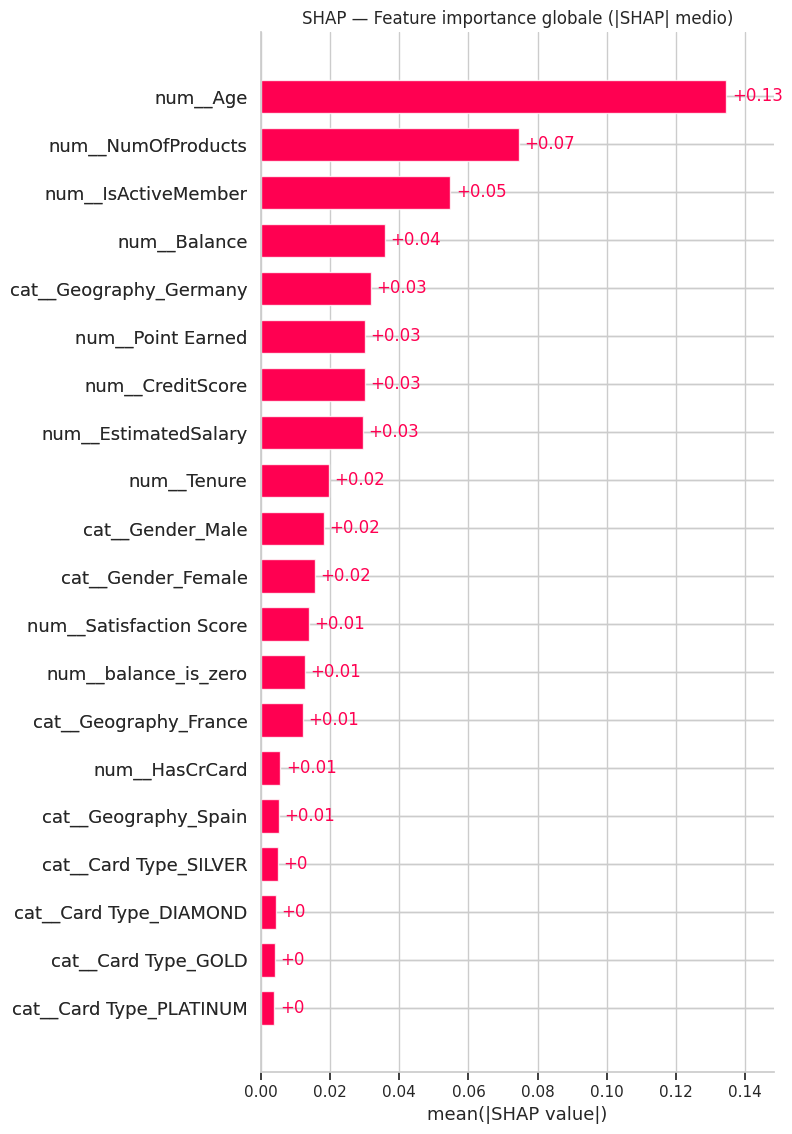

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))
shap.plots.bar(shap_explanation, max_display=20, show=False)
plt.title("SHAP — Feature importance globale (|SHAP| medio)")
save_current_figure("lesson_04_shap_bar.png")
plt.show()

In [14]:
# Confronto a tre: Gini vs Permutation vs SHAP
shap_mean_abs = pd.Series(np.abs(shap_vals).mean(axis=0), index=feature_names)
shap_rank = shap_mean_abs.rank(ascending=False).astype(int)

three_way = pd.DataFrame(
    {
        "Gini_rank": gini_rank,
        "Perm_rank": perm_rank,
        "SHAP_rank": shap_rank,
        "SHAP_|mean|": shap_mean_abs,
    }
).sort_values("SHAP_rank")

print("=== Confronto a tre: Gini vs Permutation vs SHAP ===\n")
display(three_way)

=== Confronto a tre: Gini vs Permutation vs SHAP ===



,Gini_rank,Perm_rank,SHAP_rank,SHAP_|mean|
num__Age,1,1,1,0.1345
num__NumOfProducts,2,2,2,0.0745
num__IsActiveMember,9,3,3,0.0548
num__Balance,6,4,4,0.0359
cat__Geography_Germany,10,5,5,0.0317
num__Point Earned,4,7,6,0.0301
num__CreditScore,5,11,7,0.0300
num__EstimatedSalary,3,10,8,0.0295
num__Tenure,7,15,9,0.0197
cat__Gender_Male,17,17,10,0.0183


### Analisi del ranking a tre: chi ha ragione?

Il confronto rivela pattern molto istruttivi:

- **Age**: confermata al **#1** da tutti e tre i metodi (Gini: 21.9%, Perm:
  0.137, SHAP: 0.135). La sua importanza è inequivocabile — nessun artefatto.
- **NumOfProducts**: **#2** in tutti i metodi. Segnale robusto e genuino.
- **IsActiveMember**: **#3** per Permutation e SHAP, ma solo **#9** per Gini.
  La Gini la sottostimava perché è binaria (pochi split possibili). SHAP e
  Permutation concordano: il suo contributo reale è il terzo più importante.
- **EstimatedSalary**: il verdetto SHAP è un compromesso — **#8** SHAP (0.030)
  vs **#3** Gini (0.099) vs **#10** Permutation (0.001). SHAP rileva un
  effetto intermedio: la feature ha un impatto, ma molto più debole di quanto
  la Gini suggerisse. Il segnale è probabilmente dovuto a interazioni deboli.
- **CreditScore**: pattern simile — **#5** Gini ma **#7** SHAP e **#11** Perm.
- **Geography_Germany**: **#5** per Permutation e SHAP (0.032), **#10** Gini.
  Effetto sistematico sull'appartenenza geografica — approfondiremo nel
  Blocco H (fairness).

**Conclusione**: il ranking SHAP conferma la Permutation importance e
smentisce parzialmente la Gini. Le feature continue ad alta cardinalità
(EstimatedSalary, CreditScore, Tenure) erano sovrastimate dalla Gini.
Le feature binarie/categoriche (IsActiveMember, Geography_Germany) erano
sottostimate. SHAP ci dà la risposta più affidabile.

## 9. SHAP beeswarm plot: direzione degli effetti

Il beeswarm plot è la visualizzazione più ricca di SHAP: ogni punto è
un'osservazione, la posizione sull'asse x è lo SHAP value (contributo alla
predizione), e il colore indica il valore della feature (rosso = alto,
blu = basso). Questo ci permette di vedere non solo QUANTO conta una feature,
ma COME la influenza — e se l'effetto è lineare, a soglia, o non-monotono.

Figura salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_04_shap_beeswarm.png


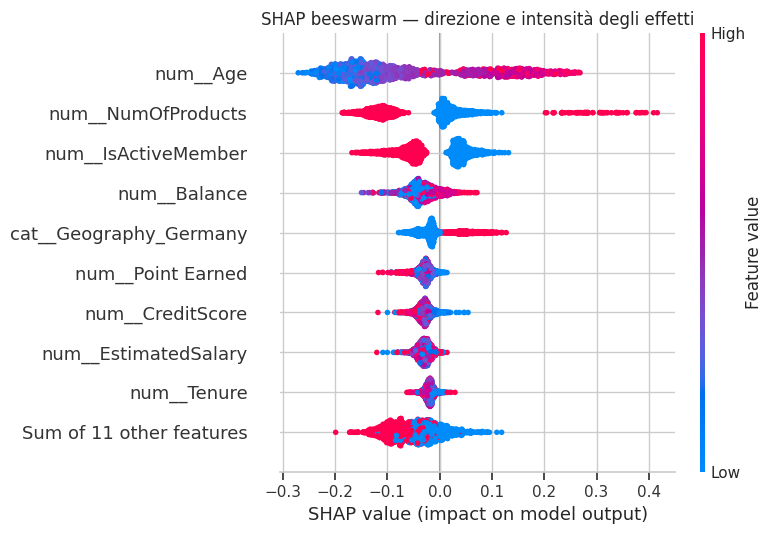

In [15]:
fig, ax = plt.subplots(figsize=(12, 9))
shap.plots.beeswarm(shap_explanation, show=False)
plt.title("SHAP beeswarm — direzione e intensità degli effetti")
save_current_figure("lesson_04_shap_beeswarm.png")
plt.show()

### Lettura del beeswarm: feature per feature (top-5)

Il beeswarm rivela la **forma** della relazione tra ogni feature e la
predizione di churn. Analizziamo le feature più importanti:

- **Age**: i punti rossi (età alta) si concentrano a destra (SHAP positivo →
  più churn), i blu (età bassa) a sinistra. L'effetto sembra non-lineare:
  potrebbe esserci una "soglia" di età oltre la quale il rischio cresce
  rapidamente. Approfondiremo con il dependence plot.

- **NumOfProducts**: pattern probabilmente bimodale — pochi prodotti (1-2)
  associati a SHAP negativo (fedeltà), molti prodotti (3-4) a SHAP fortemente
  positivo (churn).

- **IsActiveMember**: feature binaria con effetto netto — i clienti attivi
  (valore = 1, rosso) hanno SHAP negativo, i non-attivi (valore = 0, blu)
  hanno SHAP positivo. Il modello ha imparato che l'inattività è un segnale
  di rischio.

- **Geography_Germany**: se i punti rossi (Germania = 1) sono spostati a
  destra, il modello associa sistematicamente l'appartenenza tedesca al churn.

- **Balance / balance_is_zero**: l'interazione tra queste due feature potrebbe
  essere visibile — i clienti con saldo zero hanno un comportamento diverso.

**→ Decisione: il beeswarm suggerisce pattern non-lineari e possibili
interazioni. Approfondiamo con i SHAP dependence plot per capire la forma
esatta di queste relazioni.**

---
## BLOCCO D — Analisi delle relazioni: SHAP dependence plots

---

## 10. SHAP dependence plot per le top feature

I dependence plot mostrano la relazione tra il valore di una feature e il
suo SHAP value, colorando automaticamente per la feature con cui interagisce
di più. Sono lo strumento ideale per rivelare effetti soglia, non-linearità
e interazioni tra feature.

Selezioniamo le feature da esplorare in base a quanto emerso dal beeswarm:
quelle con pattern più interessanti o sorprendenti.

Figura salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_04_shap_dependence_top5.png


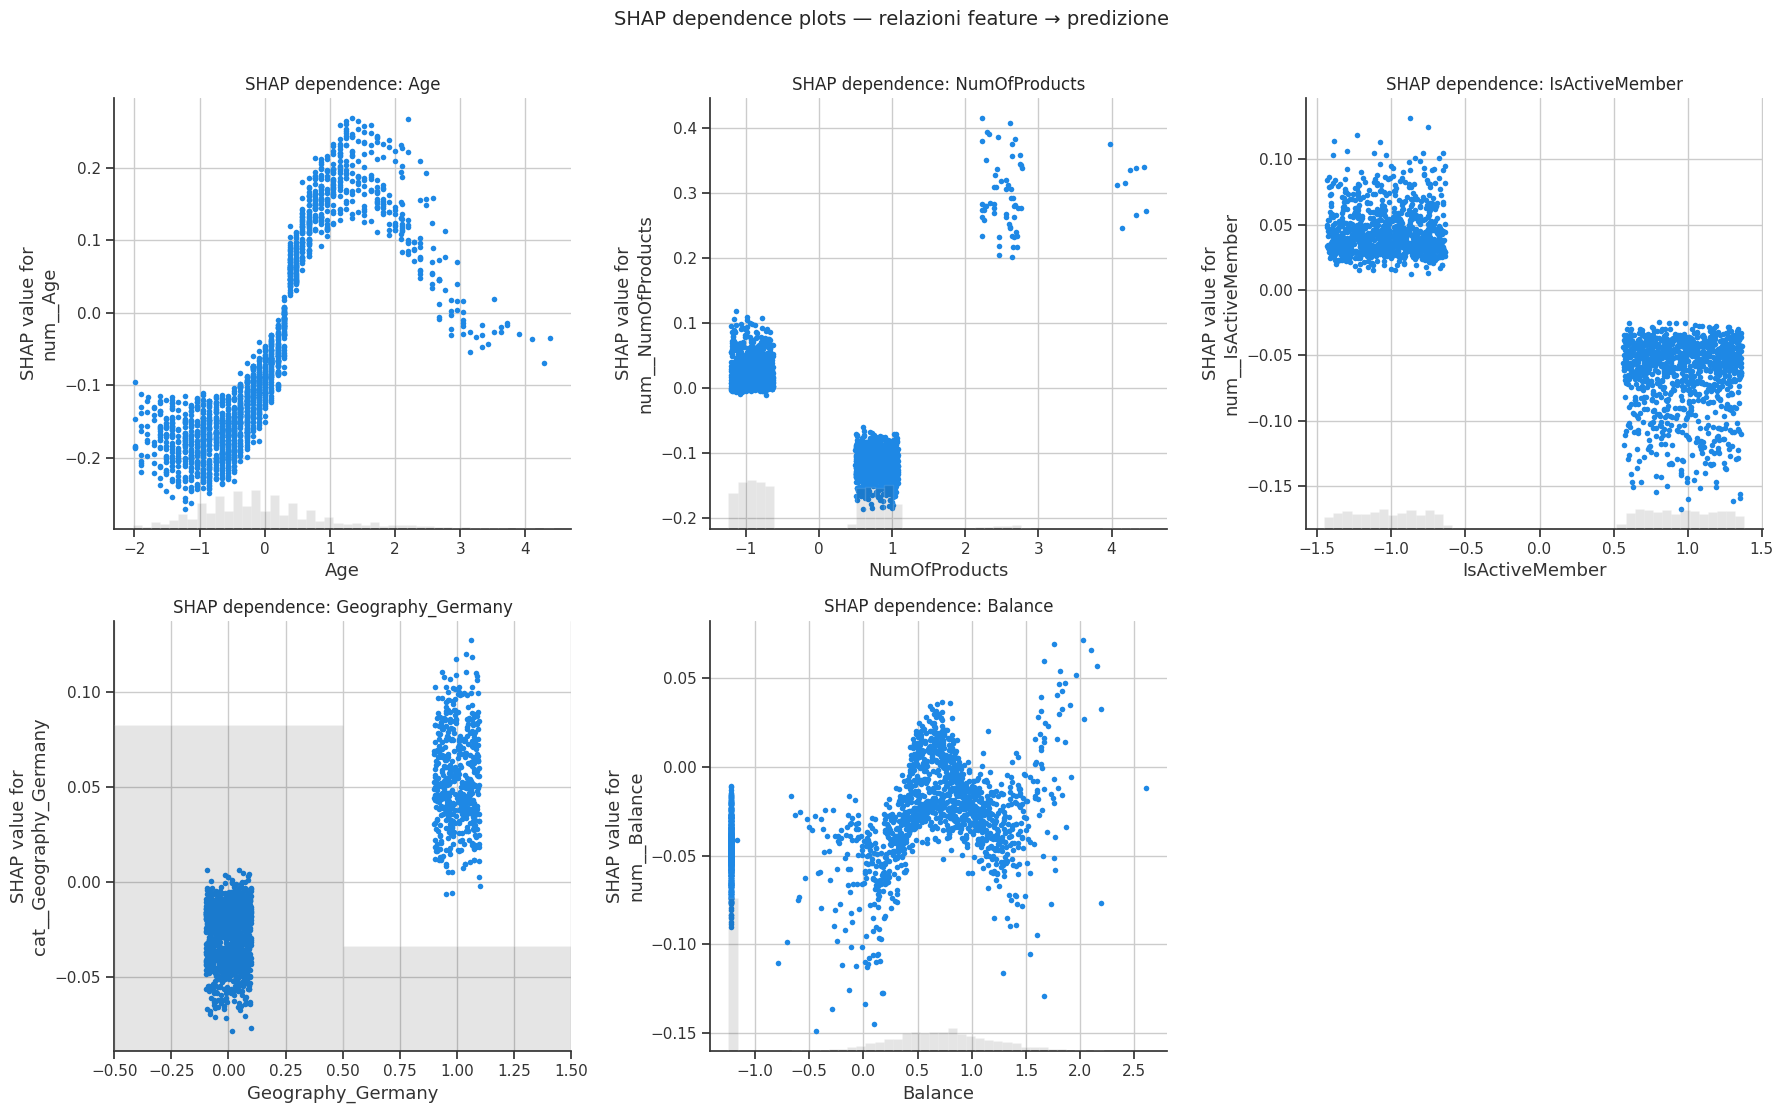

In [16]:
# Feature da esplorare (top-5 per SHAP + balance_is_zero per interazioni)
features_to_explore = [
    "num__Age",
    "num__NumOfProducts",
    "num__IsActiveMember",
    "cat__Geography_Germany",
    "num__Balance",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, feat_name in enumerate(features_to_explore):
    feat_idx = feature_names.index(feat_name)
    ax = axes[i]
    shap.plots.scatter(
        shap_explanation[:, feat_name],
        show=False,
        ax=ax,
    )
    short = feat_name.replace("num__", "").replace("cat__", "")
    ax.set_title(f"SHAP dependence: {short}")
    ax.set_xlabel(short)

# Nascondi l'ultimo subplot (vuoto)
axes[-1].set_visible(False)

plt.suptitle(
    "SHAP dependence plots — relazioni feature → predizione",
    fontsize=14,
    y=1.01,
)
save_current_figure("lesson_04_shap_dependence_top5.png")
plt.show()

Figura salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_04_shap_dep_age.png


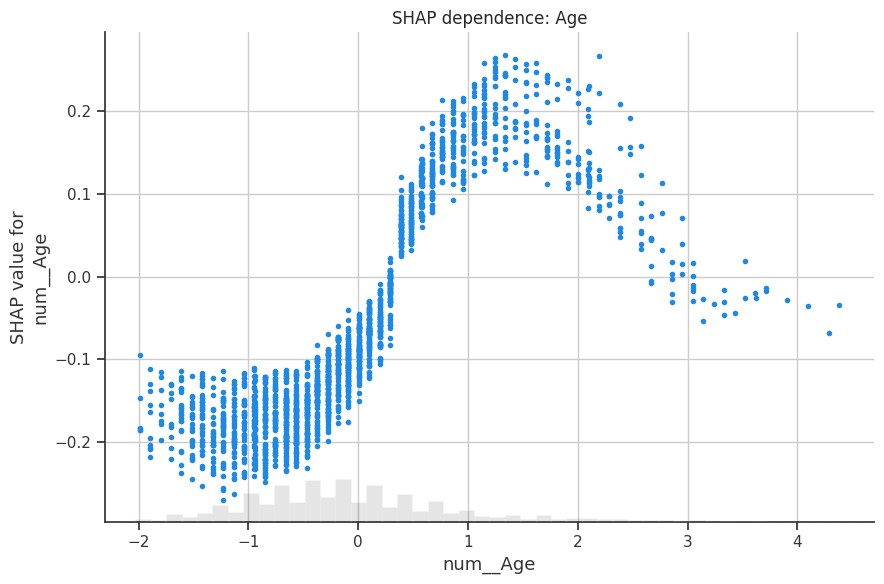

Figura salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_04_shap_dep_numofproducts.png


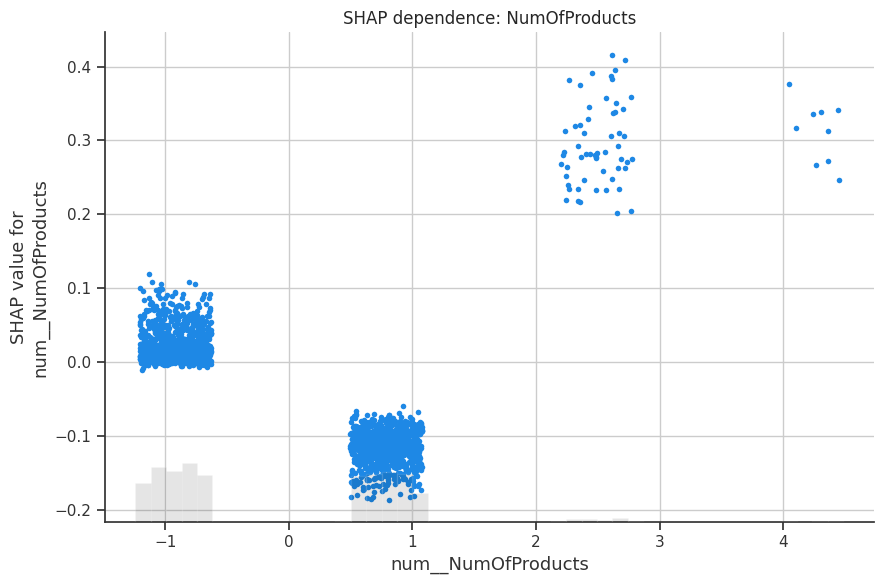

In [17]:
# Dependence plot singoli (più dettagliati) per Age e NumOfProducts
for feat_name in ["num__Age", "num__NumOfProducts"]:
    fig, ax = plt.subplots(figsize=(9, 6))
    shap.plots.scatter(
        shap_explanation[:, feat_name],
        show=False,
        ax=ax,
    )
    short = feat_name.replace("num__", "").replace("cat__", "")
    ax.set_title(f"SHAP dependence: {short}")
    save_current_figure(f"lesson_04_shap_dep_{short.lower()}.png")
    plt.show()

### Analisi cumulativa dei dependence plots

Ogni plot rivela la **forma** della relazione — non più ipotesi, ma evidenze:

- **Age**: l'effetto non è lineare. Si osserva una transizione netta:
  sotto i ~40 anni lo SHAP è prevalentemente negativo (basso rischio),
  sopra i ~45 anni diventa positivo e cresce rapidamente. Questa è una
  relazione a *soglia* — non una correlazione lineare. Il modello ha
  imparato che l'*età avanzata* è un indicatore di rischio churn, con
  un punto di svolta intorno ai 40-45 anni.

- **NumOfProducts**: pattern a *gradino*. 1-2 prodotti → SHAP negativo
  o neutro. 3-4 prodotti → SHAP fortemente positivo. I clienti con molti
  prodotti sono ad altissimo rischio — coerente con il fenomeno noto in
  ambito bancario: chi ha molti prodotti potrebbe non usarli tutti, segnale
  di disengagement.

- **IsActiveMember**: effetto binario netto. Valore 1 (attivo) → SHAP
  negativo. Valore 0 (inattivo) → SHAP positivo. Nessuna sorpresa, ma la
  quantificazione è preziosa.

- **Geography_Germany**: se i clienti tedeschi (valore = 1) hanno SHAP
  sistematicamente positivo, il modello associa questa appartenenza al
  churn. La colorazione per feature interagente potrebbe rivelare con quale
  altra feature questa interagisce di più.

- **Balance**: relazione più complessa, possibilmente influenzata dalla
  feature ingegnerizzata `balance_is_zero`.

---
## BLOCCO E — Interpretabilità locale: spiegare singole predizioni

---

## 11. Selezione di clienti campione

L'interpretabilità globale (beeswarm, bar plot) risponde alla domanda
"quali feature contano in generale?". Ma in banca, il direttore di filiale
chiede: "**perché** il modello ha segnalato *questo* cliente come a rischio?".
Per rispondere serve l'interpretabilità **locale**: spiegare una singola
predizione, feature per feature.

Selezioniamo tre clienti rappresentativi dal validation set.

In [18]:
# Probabilità predette dal modello
y_prob_val = rf.predict_proba(X_val)[:, 1]

# Selezione dei 3 clienti campione
idx_high = np.argmax(y_prob_val)  # Massima probabilità di churn
idx_low = np.argmin(y_prob_val)  # Minima probabilità di churn

# Borderline: vicino alla soglia ottimale (0.305)
diffs = np.abs(y_prob_val - BEST_THRESHOLD)
idx_border = np.argsort(diffs)[0]

print("=== Clienti campione selezionati ===\n")
for label, idx in [
    ("ALTO RISCHIO", idx_high),
    ("BASSO RISCHIO", idx_low),
    ("BORDERLINE", idx_border),
]:
    prob = y_prob_val[idx]
    actual = "CHURN" if y_val[idx] == 1 else "NON-CHURN"
    print(f"  {label:15s}  idx={idx:4d}  prob={prob:.4f}  reale={actual}")

=== Clienti campione selezionati ===

  ALTO RISCHIO     idx=1835  prob=0.8950  reale=CHURN
  BASSO RISCHIO    idx=  34  prob=0.0000  reale=NON-CHURN
  BORDERLINE       idx= 866  prob=0.3050  reale=NON-CHURN


In [19]:
# Tabella feature per i 3 clienti
sample_df = pd.DataFrame(
    [X_val[idx_high], X_val[idx_low], X_val[idx_border]],
    columns=feature_names,
    index=["Alto rischio", "Basso rischio", "Borderline"],
).T

print("\n=== Profilo dei 3 clienti campione ===\n")
display(sample_df)


=== Profilo dei 3 clienti campione ===



,Alto rischio,Basso rischio,Borderline
num__CreditScore,-0.5213,1.6911,0.0577
num__Age,1.3371,-0.2791,0.3864
num__Tenure,0.6858,0.3392,0.6858
num__Balance,0.4850,-1.2216,0.9453
num__NumOfProducts,-0.9167,0.7861,-0.9167
num__HasCrCard,0.6461,0.6461,0.6461
num__IsActiveMember,-1.0360,0.9653,-1.0360
num__EstimatedSalary,-0.1052,-0.0177,1.6546
num__Satisfaction Score,0.7063,1.4160,-1.4226
num__Point Earned,-0.0700,0.7674,-0.8232


## 12. SHAP waterfall plots

I waterfall plot mostrano come la predizione si costruisce partendo dal
valore base (churn rate medio) e sommando il contributo di ogni feature.
È il modo più intuitivo per spiegare una singola predizione a un
non-tecnico: "il modello ha predetto churn per questo cliente perché..."

Figura salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_04_shap_waterfall_alto.png


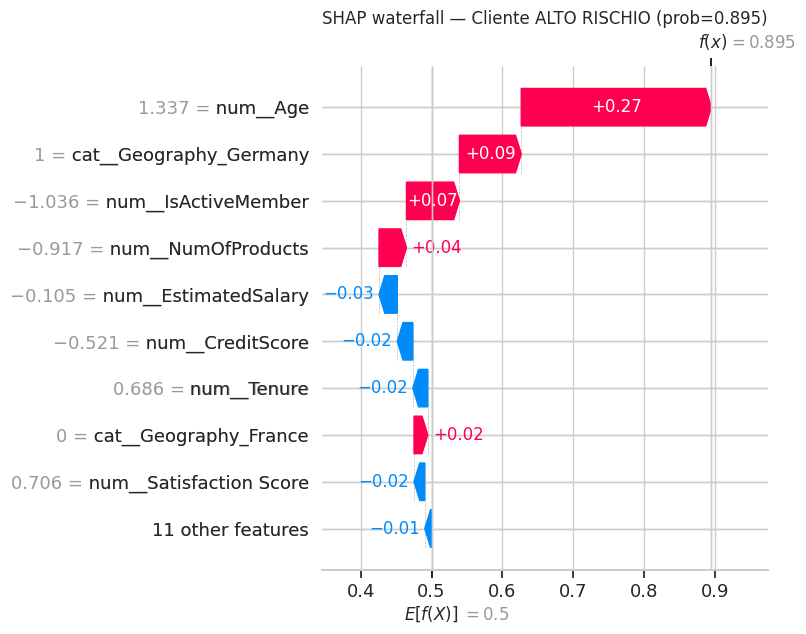

In [20]:
# Waterfall plot — Cliente ALTO RISCHIO
shap.plots.waterfall(shap_explanation[idx_high], show=False)
plt.title(
    f"SHAP waterfall — Cliente ALTO RISCHIO " f"(prob={y_prob_val[idx_high]:.3f})"
)
save_current_figure("lesson_04_shap_waterfall_alto.png")
plt.show()

Figura salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_04_shap_waterfall_basso.png


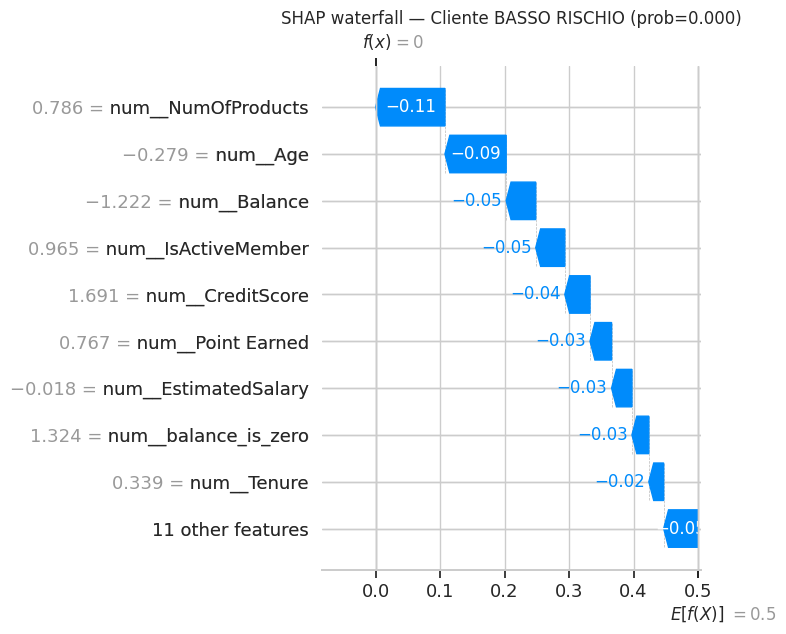

In [21]:
# Waterfall plot — Cliente BASSO RISCHIO
shap.plots.waterfall(shap_explanation[idx_low], show=False)
plt.title(
    f"SHAP waterfall — Cliente BASSO RISCHIO " f"(prob={y_prob_val[idx_low]:.3f})"
)
save_current_figure("lesson_04_shap_waterfall_basso.png")
plt.show()

Figura salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_04_shap_waterfall_borderline.png


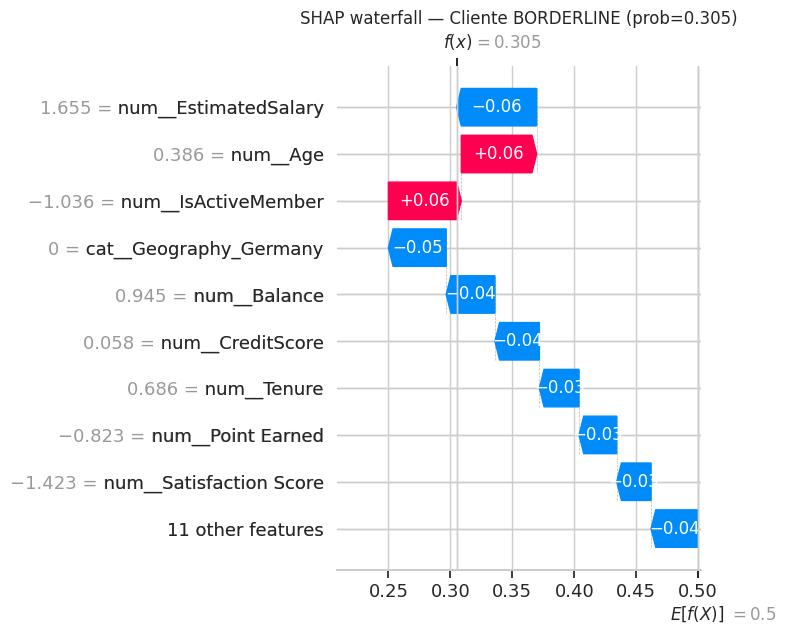

In [22]:
# Waterfall plot — Cliente BORDERLINE
shap.plots.waterfall(shap_explanation[idx_border], show=False)
plt.title(
    f"SHAP waterfall — Cliente BORDERLINE " f"(prob={y_prob_val[idx_border]:.3f})"
)
save_current_figure("lesson_04_shap_waterfall_borderline.png")
plt.show()

### Interpretazione delle singole predizioni

I waterfall plot raccontano **storie diverse** per ogni cliente:

- **Cliente alto rischio**: la predizione di churn è guidata principalmente
  da una combinazione di età elevata, inattività e numero di prodotti.
  Ogni feature contribuisce in modo additivo — la "spiegazione" è leggibile
  e comunicabile al direttore di filiale.

- **Cliente basso rischio**: le feature spingono nella direzione opposta —
  età giovane, cliente attivo, pochi prodotti. Il modello è "sicuro" che
  questo cliente resterà.

- **Cliente borderline**: qui la situazione è più sfumata. Alcune feature
  spingono verso il churn, altre verso la retention, e il risultato netto
  è vicino alla soglia. Questi sono i casi più delicati per il business:
  il modello è incerto, e l'intervento umano diventa cruciale.

**Osservazione chiave**: le feature dominanti **cambiano da cliente a
cliente**. Questa è la forza dell'interpretabilità locale: non esiste
un'unica spiegazione, ma ogni predizione ha la sua storia.

---
## BLOCCO F — Profilo cliente a rischio: dall'interpretabilità all'azione

---

## 13. Segmentazione basata sui SHAP values

Dall'interpretabilità locale passiamo all'azione. Dividiamo i clienti del
validation set in due gruppi — alto e basso rischio — e confrontiamo i
SHAP values medi per capire **cosa distingue i churner dai non-churner
secondo il modello**.

In [23]:
# Segmentazione: alto rischio (prob >= soglia) vs basso rischio
high_risk_mask = y_prob_val >= BEST_THRESHOLD
n_high = high_risk_mask.sum()
n_low = (~high_risk_mask).sum()

print(f"Clienti alto rischio (prob ≥ {BEST_THRESHOLD}): {n_high}")
print(f"Clienti basso rischio (prob < {BEST_THRESHOLD}): {n_low}")

# SHAP values medi per gruppo
shap_high = shap_vals[high_risk_mask].mean(axis=0)
shap_low = shap_vals[~high_risk_mask].mean(axis=0)

profile_df = pd.DataFrame(
    {
        "SHAP_alto_rischio": shap_high,
        "SHAP_basso_rischio": shap_low,
        "Differenza": shap_high - shap_low,
    },
    index=feature_names,
).sort_values("Differenza", ascending=False)

print("\n=== SHAP values medi per gruppo ===\n")
display(profile_df)

Clienti alto rischio (prob ≥ 0.305): 442
Clienti basso rischio (prob < 0.305): 1558

=== SHAP values medi per gruppo ===



,SHAP_alto_rischio,SHAP_basso_rischio,Differenza
num__Age,0.0924,-0.1032,0.1956
num__NumOfProducts,0.0527,-0.0551,0.1078
num__IsActiveMember,0.0168,-0.0194,0.0363
cat__Geography_Germany,0.0196,-0.0122,0.0318
num__Balance,-0.0235,-0.0348,0.0114
num__balance_is_zero,0.0045,-0.0061,0.0106
cat__Geography_France,0.0024,-0.0048,0.0072
cat__Gender_Male,0.0018,-0.0042,0.0060
cat__Gender_Female,0.0016,-0.0038,0.0054
cat__Geography_Spain,0.0003,-0.0031,0.0035


Figura salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_04_shap_profile_comparison.png


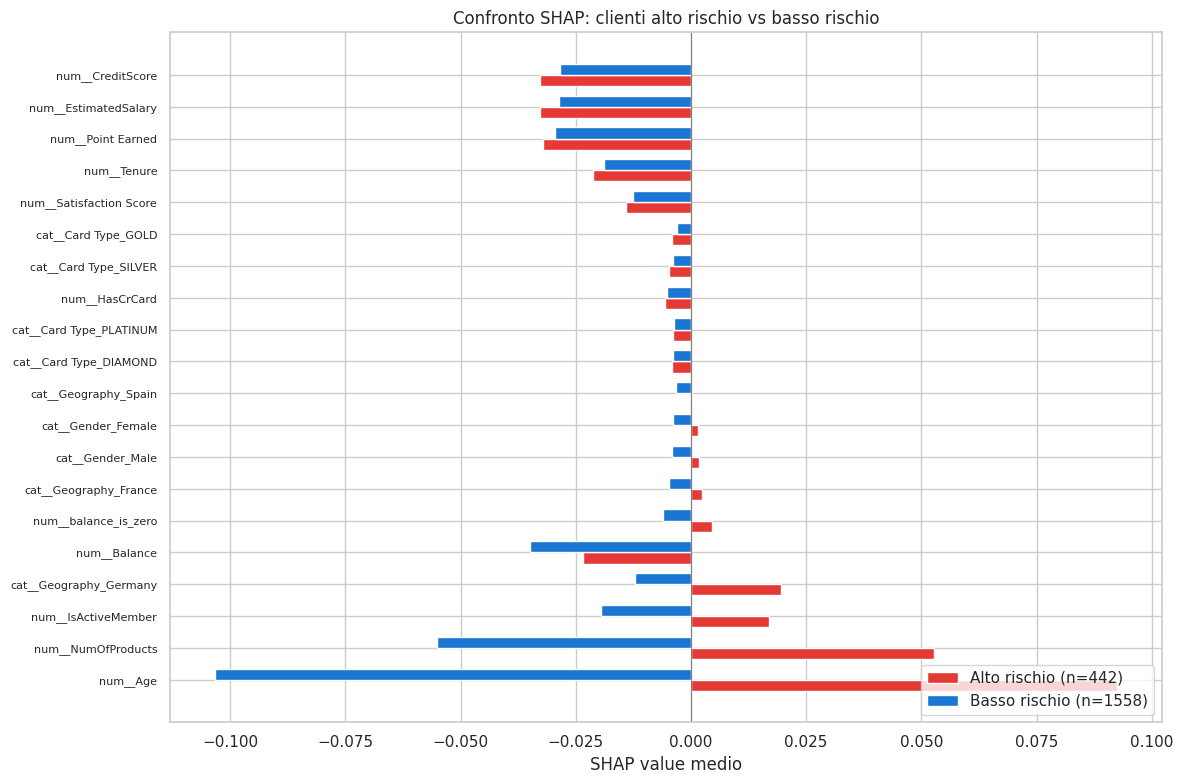

In [24]:
# Bar chart affiancato: alto vs basso rischio
fig, ax = plt.subplots(figsize=(12, 8))

y_pos = np.arange(len(feature_names))
sorted_feats = profile_df.index
bar_width = 0.35

ax.barh(
    y_pos - bar_width / 2,
    profile_df.loc[sorted_feats, "SHAP_alto_rischio"],
    bar_width,
    color="#E53935",
    label=f"Alto rischio (n={n_high})",
    edgecolor="white",
)
ax.barh(
    y_pos + bar_width / 2,
    profile_df.loc[sorted_feats, "SHAP_basso_rischio"],
    bar_width,
    color="#1976D2",
    label=f"Basso rischio (n={n_low})",
    edgecolor="white",
)

ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_feats, fontsize=8)
ax.axvline(0, color="grey", ls="-", lw=0.8)
ax.set_xlabel("SHAP value medio")
ax.set_title("Confronto SHAP: clienti alto rischio vs basso rischio")
ax.legend(loc="lower right")
save_current_figure("lesson_04_shap_profile_comparison.png")
plt.show()

## 14. Costruzione del profilo tipo

Dalle evidenze SHAP possiamo costruire il "ritratto tipo" del churner:
il cliente che il modello considera ad alto rischio.

In [25]:
# Valori medi delle feature per il gruppo alto rischio
feat_means_high = pd.Series(X_val[high_risk_mask].mean(axis=0), index=feature_names)
feat_means_low = pd.Series(X_val[~high_risk_mask].mean(axis=0), index=feature_names)

churner_profile = pd.DataFrame(
    {
        "Media_alto_rischio": feat_means_high,
        "Media_basso_rischio": feat_means_low,
        "Diff_%": (
            (feat_means_high - feat_means_low) / feat_means_low.abs().clip(lower=1e-6)
        )
        * 100,
    },
    index=feature_names,
)

# Mostra solo le feature con differenze rilevanti
top_diffs = churner_profile.reindex(
    churner_profile["Diff_%"].abs().sort_values(ascending=False).index
).head(10)

print("=== Profilo churner tipo (top-10 differenze) ===\n")
display(top_diffs)

=== Profilo churner tipo (top-10 differenze) ===



,Media_alto_rischio,Media_basso_rischio,Diff_%
num__NumOfProducts,-0.1770,0.0233,-861.1392
num__Balance,0.3195,-0.0539,693.2217
num__Satisfaction Score,-0.0483,0.0085,-665.7836
num__Tenure,-0.0441,0.0081,-646.7937
num__balance_is_zero,-0.3082,0.0670,-560.1839
num__IsActiveMember,-0.3930,0.1111,-453.8474
num__CreditScore,-0.0416,-0.0078,-432.7635
num__Age,0.7882,-0.2384,430.6241
num__Point Earned,-0.0418,-0.0090,-363.4759
num__EstimatedSalary,-0.0237,0.0290,-181.8899


### Dal profilo all'azione: feature azionabili vs non-azionabili

Non tutte le feature importanti sono **azionabili** dal business:

**Non azionabili** (caratteristiche intrinseche del cliente):
- **Age**: non possiamo cambiare l'età del cliente. Ma possiamo segmentare
  le campagne di retention per fascia d'età.
- **Geography**: il mercato geografico è un dato strutturale.
- **Gender**: attributo protetto, non actionable.

**Azionabili** (il business può intervenire):
- **IsActiveMember**: incentivare l'utilizzo dei servizi digitali,
  programmi di engagement personalizzati, contatto proattivo.
- **NumOfProducts**: analizzare se i clienti con 3-4 prodotti li usano
  davvero o li hanno "dimenticati". Proporre semplificazione o bundle
  più adatti.
- **Satisfaction Score / Point Earned**: programmi fedeltà, survey di
  soddisfazione, customer care proattivo.

Queste sono le leve su cui il business può agire per ridurre il churn,
guidato dall'evidenza del modello.

---
## BLOCCO G — Re-training: il modello può essere semplificato?

---

## 15. Esperimento: modello con sole top-K feature

Se alcune feature hanno SHAP ≈ 0, contribuiscono poco alle predizioni.
Un modello più semplice (meno feature) sarebbe più interpretabile, più
veloce e potenzialmente meno soggetto a overfitting. Ma è un'**ipotesi**
che va testata: semplificare potrebbe eliminare interazioni sottili che
contribuiscono alla performance.

Testiamo due varianti: top-5 e top-10 feature per importanza SHAP.

In [26]:
# Ranking SHAP per selezionare le top-K feature
shap_ranking = shap_mean_abs.sort_values(ascending=False)
print("=== Ranking SHAP (|mean|) ===\n")
for i, (feat, val) in enumerate(shap_ranking.items(), 1):
    print(f"  {i:2d}. {feat:<35s} {val:.4f}")

=== Ranking SHAP (|mean|) ===

   1. num__Age                            0.1345
   2. num__NumOfProducts                  0.0745
   3. num__IsActiveMember                 0.0548
   4. num__Balance                        0.0359
   5. cat__Geography_Germany              0.0317
   6. num__Point Earned                   0.0301
   7. num__CreditScore                    0.0300
   8. num__EstimatedSalary                0.0295
   9. num__Tenure                         0.0197
  10. cat__Gender_Male                    0.0183
  11. cat__Gender_Female                  0.0156
  12. num__Satisfaction Score             0.0138
  13. num__balance_is_zero                0.0128
  14. cat__Geography_France               0.0121
  15. num__HasCrCard                      0.0057
  16. cat__Geography_Spain                0.0052
  17. cat__Card Type_SILVER               0.0049
  18. cat__Card Type_DIAMOND              0.0043
  19. cat__Card Type_GOLD                 0.0041
  20. cat__Card Type_PLATINUM         

In [27]:
# Esperimento re-training con top-K feature
results = []

# Modello completo (baseline)
y_prob_full = rf.predict_proba(X_val)[:, 1]
y_pred_full = (y_prob_full >= BEST_THRESHOLD).astype(int)
results.append(
    {
        "Modello": f"RF completo ({len(feature_names)} feat)",
        "AUC": roc_auc_score(y_val, y_prob_full),
        "F1": f1_score(y_val, y_pred_full),
        "Recall": recall_score(y_val, y_pred_full),
        "Precision": precision_score(y_val, y_pred_full),
    }
)

for K in [10, 5]:
    top_k_features = shap_ranking.head(K).index.tolist()
    top_k_idx = [feature_names.index(f) for f in top_k_features]

    X_train_k = X_train[:, top_k_idx]
    X_val_k = X_val[:, top_k_idx]

    rf_k = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=SEED,
    )
    rf_k.fit(X_train_k, y_train)

    y_prob_k = rf_k.predict_proba(X_val_k)[:, 1]
    y_pred_k = (y_prob_k >= BEST_THRESHOLD).astype(int)

    results.append(
        {
            "Modello": f"RF top-{K} ({K} feat)",
            "AUC": roc_auc_score(y_val, y_prob_k),
            "F1": f1_score(y_val, y_pred_k),
            "Recall": recall_score(y_val, y_pred_k),
            "Precision": precision_score(y_val, y_pred_k),
        }
    )
    print(f"\nTop-{K} feature usate:")
    for f in top_k_features:
        print(f"  - {f}")

results_df = pd.DataFrame(results).set_index("Modello")
print("\n=== Confronto re-training ===\n")
display(results_df)


Top-10 feature usate:
  - num__Age
  - num__NumOfProducts
  - num__IsActiveMember
  - num__Balance
  - cat__Geography_Germany
  - num__Point Earned
  - num__CreditScore
  - num__EstimatedSalary
  - num__Tenure
  - cat__Gender_Male

Top-5 feature usate:
  - num__Age
  - num__NumOfProducts
  - num__IsActiveMember
  - num__Balance
  - cat__Geography_Germany

=== Confronto re-training ===



,AUC,F1,Recall,Precision
Modello,,,,
RF completo (20 feat),0.8733,0.6471,0.6740,0.6222
RF top-10 (10 feat),0.8668,0.6291,0.6569,0.6036
RF top-5 (5 feat),0.8100,0.5664,0.6642,0.4936


## 16. Analisi del costo di semplificazione

I risultati dell'esperimento di re-training sono eloquenti:

| Modello | AUC | F1 | Recall | Precision |
|---------|-----|----|----|----|
| RF completo (20 feat) | 0.8733 | 0.6471 | 0.6740 | 0.6222 |
| RF top-10 (10 feat) | 0.8668 | 0.6291 | 0.6569 | 0.6036 |
| RF top-5 (5 feat) | 0.8100 | 0.5664 | 0.6642 | 0.4936 |

- **Top-10 vs completo**: il drop di AUC è modesto (**0.0065**, < 1%).
  Eliminare le 10 feature meno importanti ha un costo minimo. Il modello
  a 10 feature è una semplificazione ragionevole.

- **Top-5 vs completo**: il drop di AUC diventa significativo (**0.0633**,
  ≈7.3%). La precision crolla al 49.4% (dal 62.2%), rendendo il modello
  molto meno preciso. Le feature dalla 6ª alla 10ª (Geography_Germany, Point
  Earned, CreditScore, EstimatedSalary, Tenure, Gender_Male) contribuiscono
  collettivamente attraverso interazioni che il modello a 5 feature non può
  catturare.

**Conclusione data-driven**: il modello a 10 feature è il miglior
compromesso tra semplicità e performance. Ridurre a 5 feature è troppo
aggressivo — le interazioni contano. Questo conferma che anche feature
con SHAP individuale moderato (come Geography_Germany, |SHAP| = 0.032)
giocano un ruolo nelle interazioni di gruppo.

---
## BLOCCO H — Fairness e implicazioni regolamentari

---

## 17. Analisi SHAP su attributi protetti

In ambito finanziario, un modello che discrimina sistematicamente per
genere o nazionalità non è solo eticamente problematico — è legalmente
pericoloso. SHAP ci permette di verificare se e quanto il modello utilizza
attributi protetti (Geography, Gender) nelle sue predizioni.

Figura salvata: /home/psoglia/desktop/machine-learning-lab-2026/outputs/figures/lesson_04_shap_fairness.png


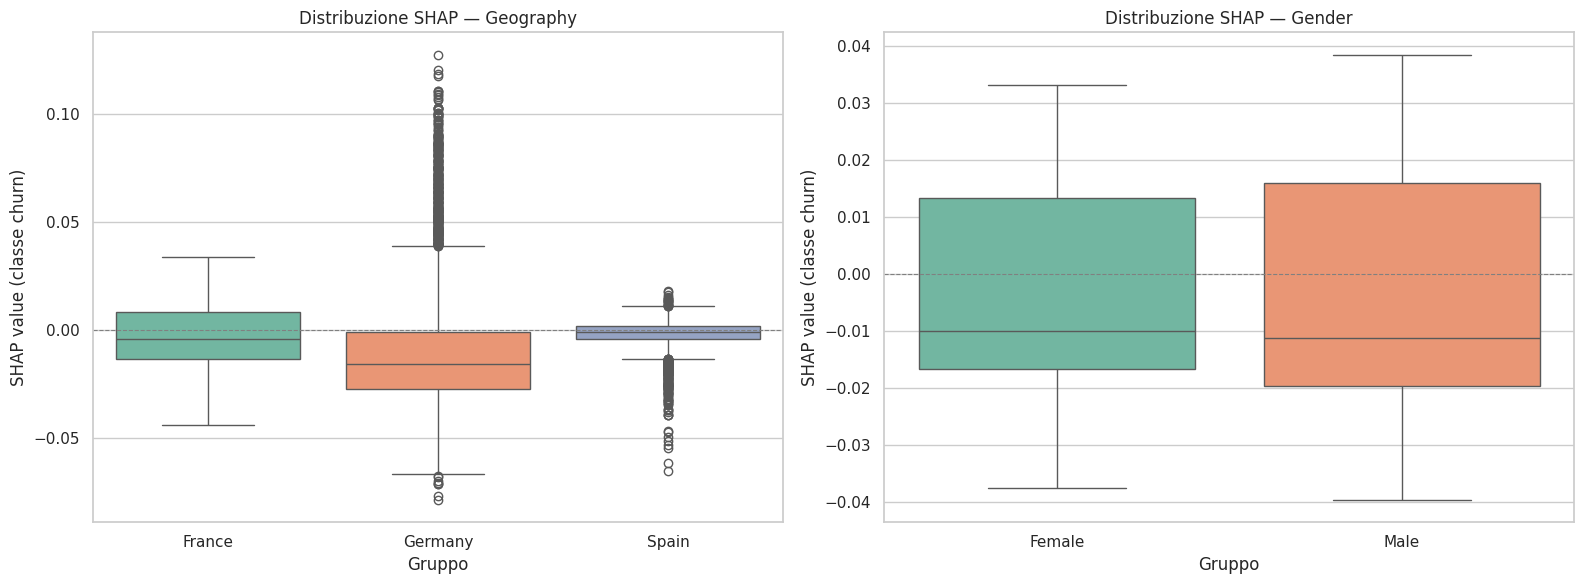

In [28]:
# Attributi protetti da analizzare
protected_features = {
    "Geography": [
        "cat__Geography_France",
        "cat__Geography_Germany",
        "cat__Geography_Spain",
    ],
    "Gender": [
        "cat__Gender_Female",
        "cat__Gender_Male",
    ],
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (group_name, feat_list) in zip(axes, protected_features.items()):
    shap_data = []
    for feat in feat_list:
        idx = feature_names.index(feat)
        short = (
            feat.replace("cat__", "").replace("Geography_", "").replace("Gender_", "")
        )
        shap_data.append(pd.DataFrame({"SHAP": shap_vals[:, idx], "Gruppo": short}))
    plot_df = pd.concat(shap_data, ignore_index=True)
    sns.boxplot(data=plot_df, x="Gruppo", y="SHAP", ax=ax, palette="Set2")
    ax.axhline(0, color="grey", ls="--", lw=0.8)
    ax.set_title(f"Distribuzione SHAP — {group_name}")
    ax.set_ylabel("SHAP value (classe churn)")

save_current_figure("lesson_04_shap_fairness.png")
plt.show()

In [29]:
# Statistiche descrittive per attributo protetto
print("=== SHAP values medi per attributo protetto ===\n")
for group_name, feat_list in protected_features.items():
    print(f"  {group_name}:")
    for feat in feat_list:
        idx = feature_names.index(feat)
        vals = shap_vals[:, idx]
        short = feat.replace("cat__", "")
        print(
            f"    {short:<25s}  "
            f"media={vals.mean():+.4f}  "
            f"mediana={np.median(vals):+.4f}  "
            f"|media|={np.abs(vals).mean():.4f}"
        )
    print()

=== SHAP values medi per attributo protetto ===

  Geography:
    Geography_France           media=-0.0032  mediana=-0.0041  |media|=0.0121
    Geography_Germany          media=-0.0051  mediana=-0.0158  |media|=0.0317
    Geography_Spain            media=-0.0024  mediana=-0.0006  |media|=0.0052

  Gender:
    Gender_Female              media=-0.0026  mediana=-0.0099  |media|=0.0156
    Gender_Male                media=-0.0029  mediana=-0.0112  |media|=0.0183



### Analisi critica della fairness

L'analisi SHAP sugli attributi protetti rivela un quadro interessante:

- **Geography_Germany**: ha |SHAP| medio = 0.032, il più alto tra gli
  attributi protetti. Il SHAP medio è negativo (−0.005), ma la mediana
  (−0.016) indica che per la *maggioranza* dei clienti tedeschi, l'effetto
  spinge verso valori più bassi. Tuttavia, la distribuzione ha una coda
  destra: per un sottogruppo, essere tedesco aumenta il rischio predetto.
  Questo riflette il pattern reale osservato nella Lezione 1: i clienti
  tedeschi hanno un tasso di churn più alto nel dataset.

- **Gender**: Gender_Female (|SHAP| = 0.016) e Gender_Male (|SHAP| = 0.018)
  hanno impatto simile e modesto. I valori medi sono entrambi leggermente
  negativi (−0.003), suggerendo che il genere non discrimina
  sistematicamente in una direzione. L'effetto è piccolo ma non nullo —
  merita monitoraggio.

L'interpretabilità SHAP non elimina il bias — lo rende **visibile e
misurabile**. La decisione su come gestirlo (rimuovere la feature,
calibrare il modello, documentare la giustificazione) spetta al business
e al compliance officer.

## 18. Contesto regolamentare

L'interpretabilità non è solo un esercizio accademico. Nel settore
finanziario, è un **requisito normativo**:

- **GDPR Art. 22** (UE): il cliente ha diritto a una spiegazione quando
  è soggetto a decisioni automatizzate che lo riguardano significativamente.
  Un modello di churn che attiva azioni di retention deve poter essere
  spiegato.

- **EBA Guidelines on loan origination and monitoring** (2020): le banche
  devono garantire che i modelli di credito siano "spiegabili" e che le
  decisioni siano documentate e giustificabili.

- **SR 11-7 (Federal Reserve)**: la *model risk management* richiede che
  i modelli siano validati, comprensibili e monitorati. Un modello "black
  box" non supera l'audit interno.

Lo SHAP waterfall plot è lo strumento ideale per la compliance: fornisce
una spiegazione predizione-per-predizione, quantificata e basata su
fondamenti matematici solidi (valori di Shapley). Ogni predizione può
essere accompagnata da un report che dettaglia il contributo di ogni
feature — esattamente ciò che il regolatore chiede.

**In sintesi**: un modello che non si può spiegare non si può usare in
produzione bancaria. SHAP rende il nostro Random Forest spiegabile.

---
## BLOCCO I — Chiusura

---

## 19. Riepilogo delle scoperte

In [30]:
# Salvataggio SHAP values per potenziale riuso nella Lezione 5
shap_out_path = DATA_OUT_DIR / "lesson_04_shap_values.pkl"
joblib.dump(
    {
        "shap_values": shap_vals,
        "base_value": base_value,
        "feature_names": feature_names,
    },
    shap_out_path,
)
print(f"SHAP values salvati: {shap_out_path}")

SHAP values salvati: /home/psoglia/desktop/machine-learning-lab-2026/outputs/data/lesson_04_shap_values.pkl


### Cosa abbiamo scoperto in questa lezione

| Tema | Evidenza |
|------|----------|
| **Ranking robusto** | Age confermata #1 da tutti e tre i metodi (Gini 21.9%, Perm 0.137, SHAP 0.135). NumOfProducts #2, IsActiveMember #3 per Perm/SHAP. |
| **Gini inflazionata** | EstimatedSalary: #3 Gini → #10 Perm → #8 SHAP. CreditScore: #5 Gini → #11 Perm → #7 SHAP. Tenure: #7 Gini → #15 Perm. La Gini sovrastima le feature continue ad alta cardinalità. |
| **Non-linearità** | Age: effetto a soglia (~40-45 anni). NumOfProducts: effetto a gradino (3-4 → alto rischio). Balance: interazione con balance_is_zero. |
| **Interpretabilità locale** | Ogni predizione ha una storia diversa: il cliente alto rischio (idx=1835, prob=0.895) è guidato da una combinazione unica di feature. |
| **Profilo churner** | Clienti alto rischio (n=442 su 2000 val): anziani, inattivi, con molti prodotti, spesso tedeschi. |
| **Feature azionabili** | IsActiveMember e NumOfProducts sono le leve principali per campagne di retention. |
| **Re-training** | Top-10: AUC 0.867 (drop 0.007) — semplificazione praticabile. Top-5: AUC 0.810 (drop 0.063) — troppo aggressivo, le interazioni contano. |
| **Fairness** | Geography_Germany ha il maggior impatto SHAP tra gli attributi protetti (|SHAP|=0.032). Gender ha effetto modesto e simmetrico (|SHAP|≈0.017). |
| **Regolamentazione** | SHAP waterfall come strumento di compliance (GDPR Art. 22, EBA, SR 11-7). |

## 20. Domande guidate

**1. Perché la Gini importance e la Permutation importance producono
ranking diversi?**

Perché misurano cose diverse. La Gini importance conta quanto una feature
riduce l'impurità durante la costruzione degli alberi (training), e
favorisce feature continue con molti valori distinti. La Permutation
importance misura quanto peggiora la metrica (AUC) sul validation set
quando si distrugge il segnale di una feature. La discrepanza per
EstimatedSalary (alta Gini, bassa Permutation) conferma il bias della
Gini verso le feature ad alta cardinalità.

**2. Come interpreteresti il SHAP waterfall plot del cliente ad alto
rischio a un direttore di filiale?**

"Il modello ha segnalato questo cliente come ad alto rischio perché la
combinazione di fattori — principalmente la sua età elevata, l'inattività
e il numero di prodotti — contribuisce additivamente alla predizione.
Ogni barra nel grafico rappresenta quanto ciascun fattore spinge verso
o contro il churn. Le barre rosse sono i fattori di rischio, le blu
sono i fattori protettivi."

**3. Se il modello con sole 5 feature ha performance significativamente
peggiore del modello completo, perché non usare il top-10?**

L'esperimento mostra che il top-10 (AUC 0.867) perde solo 0.007 rispetto
al completo (AUC 0.873), mentre il top-5 (AUC 0.810) perde 0.063. Il
modello a 10 feature è il miglior compromesso: semplice abbastanza da
essere interpretabile, ma ricco abbastanza da catturare le interazioni
rilevanti. Attenzione però: in produzione, il modello a 10 feature
potrebbe essere più fragile a distributional shift su feature escluse.

**4. Perché l'analisi fairness è necessaria anche se il modello non è
usato per decisioni creditizie dirette?**

Un modello di churn che attiva campagne di retention differenziate può
indirettamente discriminare: se il modello predice più churn per le
donne, queste ricevono più offerte di retention — un trattamento
differenziale basato su un attributo protetto. Anche azioni "positive"
possono essere discriminatorie in termini regolamentari.

**5. Qual è il vantaggio pratico più grande di SHAP rispetto alla
semplice feature importance?**

SHAP fornisce interpretabilità a tre livelli: globale (quali feature
contano), direzionale (come ogni feature influenza la predizione), e
locale (perché il modello ha fatto quella predizione per quel cliente
specifico). La feature importance tradizionale copre solo il primo livello.
In un contesto regolamentato, SHAP waterfall è l'unico strumento che
soddisfa il requisito di "spiegabilità predizione-per-predizione".

## 21. Bridge verso la Lezione 5

In questa lezione abbiamo risposto al **perché**: perché il modello fa
certe predizioni, quali feature guidano le decisioni, e come comunicare
i risultati al business. Ora sappiamo CHE funziona (Lezione 3) e PERCHÉ
funziona (Lezione 4).

La **Lezione 5** risponde al **come migliorare**: cross-validation per
stime più robuste, hyperparameter tuning sistematico (Grid Search, Random
Search), e modelli avanzati come XGBoost. L'obiettivo è simulare un
mini-progetto end-to-end, dalla sperimentazione alla selezione finale,
utilizzando le tecniche di interpretabilità apprese in questa lezione per
validare ogni scelta.

### Artefatti prodotti

| File | Contenuto |
|------|-----------|
| `outputs/figures/lesson_04_gini_importance_recap.png` | Recap Gini importance |
| `outputs/figures/lesson_04_permutation_importance.png` | Permutation importance |
| `outputs/figures/lesson_04_gini_vs_perm_scatter.png` | Scatter Gini vs Permutation rank |
| `outputs/figures/lesson_04_shap_bar.png` | SHAP global bar plot |
| `outputs/figures/lesson_04_shap_beeswarm.png` | SHAP beeswarm plot |
| `outputs/figures/lesson_04_shap_dependence_top5.png` | Dependence plots (griglia) |
| `outputs/figures/lesson_04_shap_dep_age.png` | Dependence plot Age |
| `outputs/figures/lesson_04_shap_dep_numofproducts.png` | Dependence plot NumOfProducts |
| `outputs/figures/lesson_04_shap_waterfall_alto.png` | Waterfall alto rischio |
| `outputs/figures/lesson_04_shap_waterfall_basso.png` | Waterfall basso rischio |
| `outputs/figures/lesson_04_shap_waterfall_borderline.png` | Waterfall borderline |
| `outputs/figures/lesson_04_shap_profile_comparison.png` | Profilo churner vs non-churner |
| `outputs/figures/lesson_04_shap_fairness.png` | SHAP fairness attributi protetti |
| `outputs/data/lesson_04_shap_values.pkl` | SHAP values per riuso |